## DATA ANALYSIS PYTHON PROJECT APPROACH 2 - BLINKIT ANALYSIS

### Import Libraries

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # advanced charts


### Importing Data

In [95]:
df= pd.read_excel('BlinkIT Grocery Data.xlsx')
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [96]:
df.tail()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


### Detail of Dataset

In [97]:
print("The Metatdata of the dataset:",df.shape)

The Metatdata of the dataset: (8523, 12)


In [98]:
print("No. of Rows in the dataset:",df.shape[0])

No. of Rows in the dataset: 8523


In [99]:
print("No. of Columns in the dataset:",df.shape[1])

No. of Columns in the dataset: 12


### All Columns of Dataset

In [100]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

### Column's information

In [101]:
df.info

<bound method DataFrame.info of      Item Fat Content Item Identifier              Item Type  \
0             Regular           FDX32  Fruits and Vegetables   
1             Low Fat           NCB42     Health and Hygiene   
2             Regular           FDR28           Frozen Foods   
3             Regular           FDL50                 Canned   
4             Low Fat           DRI25            Soft Drinks   
...               ...             ...                    ...   
8518          low fat           NCT53     Health and Hygiene   
8519          low fat           FDN09            Snack Foods   
8520          low fat           DRE13            Soft Drinks   
8521              reg           FDT50                  Dairy   
8522              reg           FDM58            Snack Foods   

      Outlet Establishment Year Outlet Identifier Outlet Location Type  \
0                          2012            OUT049               Tier 1   
1                          2022            OUT018  

### Column Datatypes

In [102]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

### Statictics of Dataset

In [103]:
df.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2016.450546,0.066132,12.857645,140.992783,3.965857
std,3.189396,0.051598,4.643456,62.275067,0.605651
min,2011.000000,0.000000,4.555000,31.290000,1.000000
25%,2014.000000,0.026989,8.773750,93.826500,4.000000
50%,2016.000000,0.053931,12.600000,143.012800,4.000000
75%,2018.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


### Finding the Duplicates

In [104]:
df.duplicated().sum()

0

### Finding the Nulls

In [105]:
df.isna().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

### Data Cleaning - 'LF' and 'reg' in 'Item Fat Content' values

In [106]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [107]:
df['Item Fat Content']=df['Item Fat Content'].replace({'reg':'Regular','LF':'Low Fat','low fat':'Low Fat'})

In [108]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


### **BUSINESS REQUIREMENTS**

### KPI REQUIREMENT

In [109]:
# Total sales
total_sales = df['Sales'].sum()

#Average Sales
avg_sales = df['Sales'].mean()

#No of Items sold
no_of_items = df['Sales'].count()

# Average Rating
avg_rating = df['Rating'].mean()

# Display
print(f"Total Sales: {total_sales:.2f}")
print(f"Average Sales: {avg_sales:.2f}")
print(f"No. of Items Sold: {no_of_items:,.0f}")
print(f"Average Rating: {avg_rating:,.2f}")

Total Sales: 1201681.49
Average Sales: 140.99
No. of Items Sold: 8,523
Average Rating: 3.97


### Charts Requirements

### 1. Total Sales distribution by Fat Content(Donut Chart)

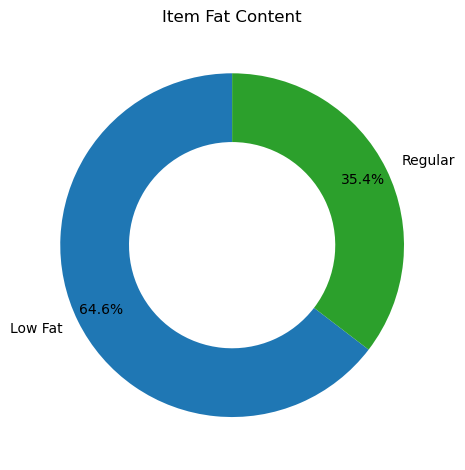

In [110]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()

#fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#1f77b4', '#2ca02c']
plt.pie(sales_by_fat, labels= sales_by_fat.index, colors=colors,
                        wedgeprops={'width': 0.4},
                        startangle=90, 
                        autopct = '%1.1f%%',
                        pctdistance=0.85)
plt.title('Item Fat Content')
plt.tight_layout()
plt.show()

### Insight: Sales Distribution by Item Fat Content
The donut chart titled "Item Fat Content" provides a clear visual comparison between the total sales of products categorized by their fat content — namely, Low Fat and Regular.

### Key Observations:
1. Low Fat items account for 64.6% of total sales.
2.  Regular fat content items account for only 35.4% of total sales.

### Interpretation:
This chart indicates that consumers prefer low-fat items significantly more than regular-fat alternatives. With nearly two-thirds of the total sales attributed to low-fat products, it reflects a trend or demand for health-conscious or diet-friendly options among customers.

### 2.Total Sales distribution by Item Type(Bar Chart)

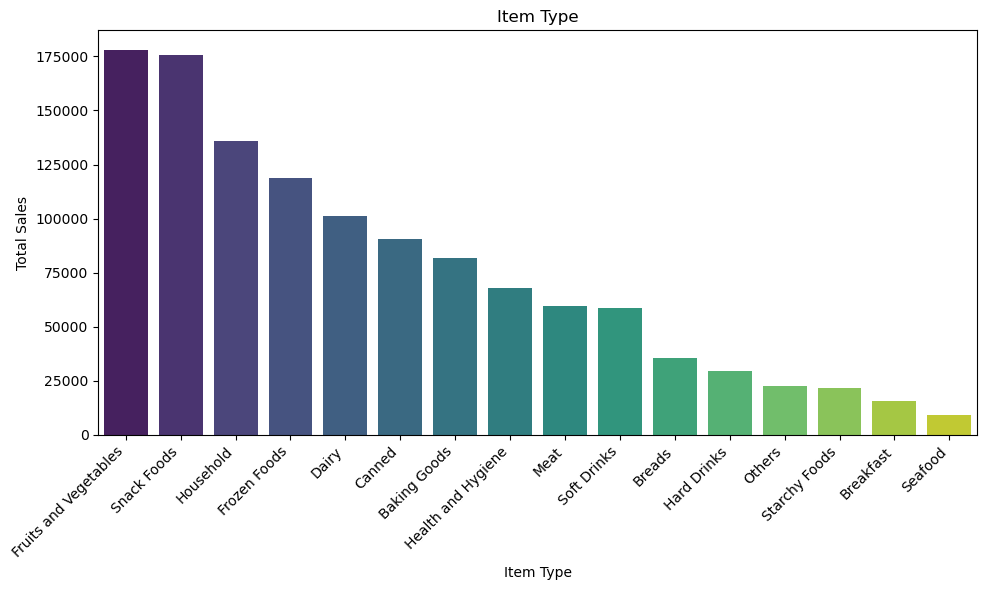

In [111]:
sales_by_item_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=sales_by_item_type.index, y=sales_by_item_type.values,hue=sales_by_item_type.index, palette='viridis',legend=False)
plt.xticks(rotation=45, ha= 'right')
plt.ylabel('Total Sales')
plt.xlabel('Item Type')
plt.title('Item Type')
plt.tight_layout()
plt.show()

### Insights: Sales by Item Type
This vertical bar chart shows the total sales for each item category, sorted from highest to lowest.

### Top Performing Categories:
1. **Fruits and Vegetables** – highest overall sales
2. **Snack Foods** – slightly below Fruits and Veg, still very strong
3. **Household, Frozen Foods, and Dairy** – also contribute significantly

These categories are likely core drivers of revenue and should be prioritized in marketing, promotions, and inventory planning.

### Mid-Level Performers:
1. **Canned, Baking Goods, Health and Hygiene**
2. These show consistent but moderate sales and may respond well to seasonal campaigns or bundling strategies.
 
### Low Performing Categories:
1. **Seafood, Breakfast, Starchy Foods, Others,** and **Hard Drinks**
2. These have noticeably lower sales volume and could indicate:
    1. Low demand
    2. Limited stock or visibility
    3. Niche or premium pricing
    4. Seasonal trends

## Business Implications:
1. **Product Focus:** Invest more in top 5 categories — they account for the bulk of revenue.
2. **Inventory Strategy:** Optimize stock for low sellers like Seafood to avoid overstock.
3. **Promotion Targeting:**	Run targeted promotions for mid-tier items to boost sales.
4. **New Product Dev:**	Consider introducing variants of top sellers like fruits/snacks.

### 3. Fat Content by outlet tier for total sales(Cluster Bar Chart)

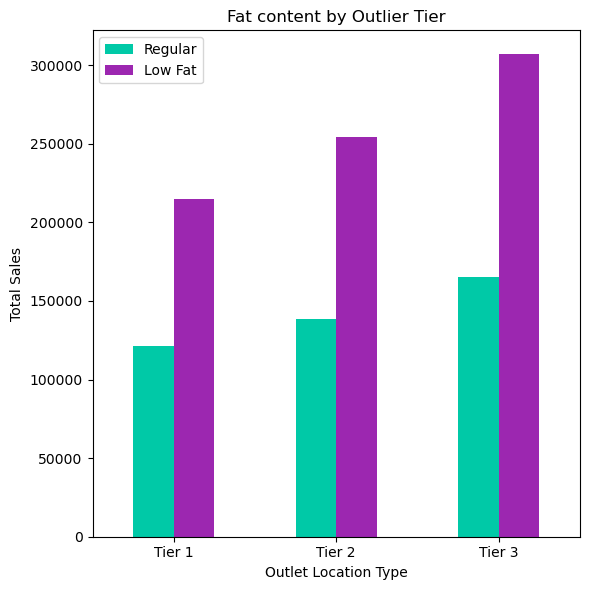

In [112]:
grouped = df.groupby(['Item Fat Content', 'Outlet Location Type'])['Sales'].sum().unstack('Item Fat Content')
grouped = grouped[['Regular', 'Low Fat']]
colors =  ['#00C9A7', '#9C27B0']

grouped.plot(kind='bar', figsize=(6,6), color = colors)
plt.xlabel('Outlet Location Type')
plt.xticks(rotation=0)
plt.ylabel('Total Sales')
plt.title('Fat content by Outlier Tier')
plt.legend()
plt.tight_layout()
plt.show()


### Insights: Fat Content by Outlet Tier
The chart compares total sales of "Low Fat" and "Regular" items across 3 outlet location types: 
Tier 1,Tier 2, and Tier 3.

### **1. Low Fat items consistently outsell Regular items**
1. In all three tiers, "Low Fat" products have significantly higher total sales than "Regular" ones.

2. This indicates a strong customer preference for Low Fat products, regardless of outlet location.

### **Sales increase with higher outlet tiers**
1. Both Regular and Low Fat sales rise from Tier 1 → Tier 3.
    1. **Tier 1:** Lowest total sales
    2. **Tier 3:** Highest total sales for both fat types

So,

2. Tier 3 outlets might be in urban or high-traffic areas.

3. They attract more health-conscious or higher-spending customers

### **Implications for business strategy:**
1. **Product focus:** Continue stocking more Low Fat items in all outlet tiers. 
2. **Outlet strategy:**	Consider promoting healthy/low-fat ranges more heavily in Tier 3 outlets 
3. **Marketing:** Use Tier 3 locations for new Low Fat product launches or campaigns

### 4. Total Sales by Outlet Establishment(Line Chart)

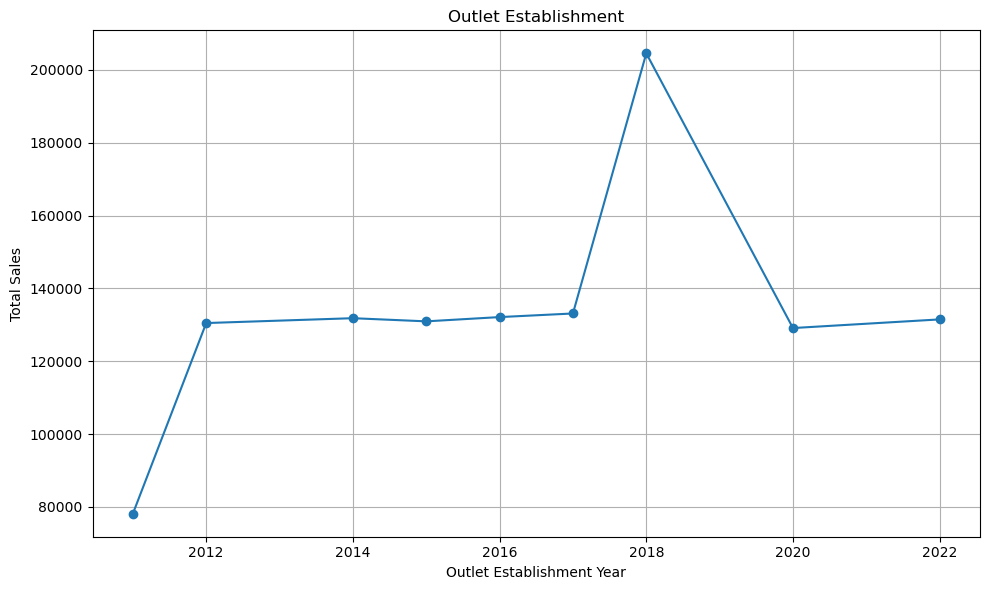

In [113]:
sales_by_outlet_year = df.groupby('Outlet Establishment Year')['Sales'].sum()

plt.figure(figsize=(10,6))
plt.plot(sales_by_outlet_year.index, sales_by_outlet_year.values, marker='o',linestyle='-')
plt.title('Outlet Establishment')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.grid()
plt.tight_layout()
plt.show()

### Insights: Outlet Establishment
This line chart displays how total sales vary based on the year in which outlets were established.

### Sales peaked for outlets established in 2018
1. 2018 shows a significant spike in total sales, reaching the highest value on the chart.
2. This suggests that outlets established in 2018 are the top-performing outlets in terms of sales.
3. **Possible reasons:**
    1. New outlets in 2018 may have opened in high-demand locations
    2. Effective launch promotions or product placements

### Outlets established in 2011 had the lowest sales
1. The lowest point on the chart corresponds to 2011.
2. This could be due to:
    1. Smaller or fewer outlets established that year
    2. Less optimized outlet strategy or product range at that time

### Stable sales trend across 2012–2017 and post-2019
1. Outlets from 2012 to 2017 show minor fluctuations in total sales (~130k)
2. Similarly, after the 2018 spike, the trend stabilizes again in 2020 and 2022
3. Indicates a consistent business strategy over those years

### 5. Sales by Outlet Size(Pie/ Donut Chart)

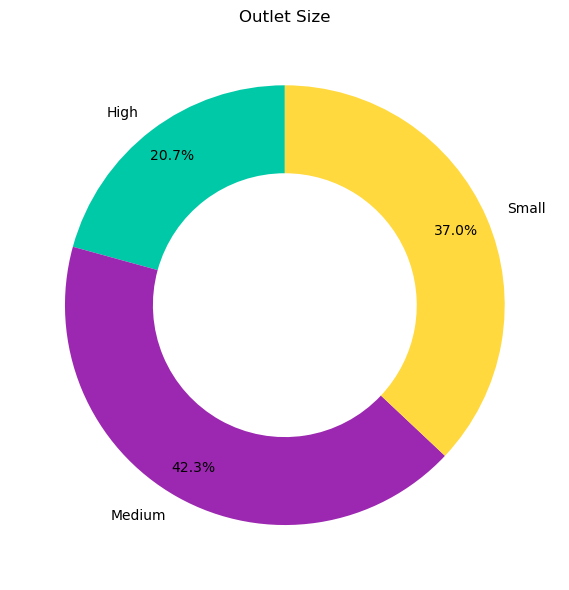

In [114]:
sales_by_outlet_size = df.groupby('Outlet Size')['Sales'].sum()

fig, ax = plt.subplots(figsize=(6,6)) 
colors= ['#00C9A7','#9C27B0','#FFD93D']
plt.pie(sales_by_outlet_size, labels =sales_by_outlet_size.index,
                              colors = colors, 
                              wedgeprops={'width':0.4},
                              startangle = 90,
                              autopct='%1.1f%%', pctdistance=0.85)
plt.title('Outlet Size')
plt.tight_layout()
plt.show()

### Insights: Outlet Size
This donut chart represents the percentage share of total sales contributed by different outlet sizes: 
1. Small
2. Medium
3. High

### Medium-sized outlets contribute the highest sales (42.3%)
1. This category accounts for nearly half of the total sales.

2.  Indicates that **medium outlets are the most productive or have the highest footfall**.

### Small outlets also perform well (37.0%)
1. Small outlets are not far behind and contribute over one-third of total sales.

2. Suggests that even with limited space, they are effectively selling products — likely due to better location (e.g., convenience stores in dense areas).

### High-sized outlets contribute the least (20.7%)
1. Despite having more space and likely a broader range of products, they generate the lowest sales among the three.
2. Possible reasons:
   1. Higher maintenance costs
   2. Lower customer density
   3. Less efficient space usage

### Business Recommendations:
1. **Medium outlets perform the best:**	Focus future expansions on medium-format stores
2. **Small outlets are still strong** Consider adding more small outlets in urban areas
3. **High outlets underperform** Audit high-size stores: optimize layout or marketing

### 6. Sales by Outlet Location(Funnel Chart)

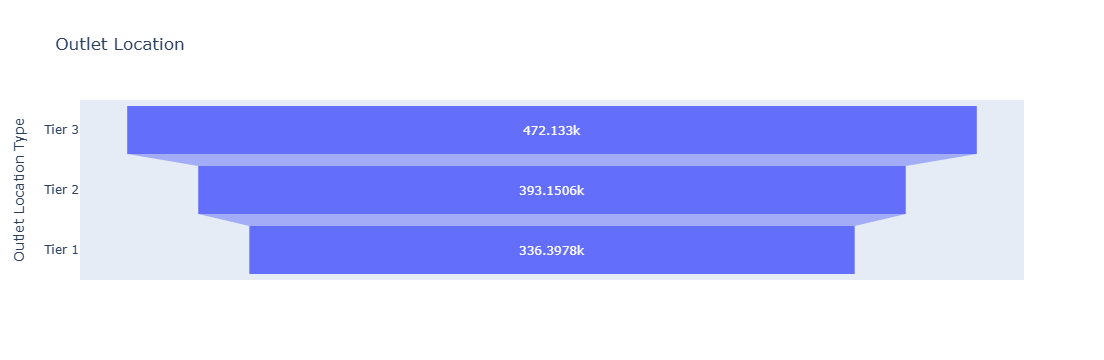

In [115]:
import plotly.express as px 
sales_by_outlet_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
sales_by_outlet_location=sales_by_outlet_location.sort_values('Sales',ascending = False)

fun_fig = px.funnel(sales_by_outlet_location,
                       x= 'Sales', y= 'Outlet Location Type',
                       title = 'Outlet Location')
fun_fig.show()

### Insights: Outlet Location
This funnel chart shows the total sales contributed by outlets in different location tiers:

Tier 3	472.1k (Total Sales)
Tier 2	393.1k (Total Sales)
Tier 1	336.3k (Total Sales)

### Tier 3 outlets contribute the most sales
1. Tier 3 (small towns or rural areas) leads with 472.1k, making up the largest funnel layer.

2. These locations are often underserved, so less competition and strong demand could drive sales.

### Tier 2 outlets are solid performers
1. Tier 2 (medium cities) contributes 393.1k, indicating strong performance.

2. Likely due to growing urbanization and rising consumer spending in mid-tier cities.

### Tier 1 (urban/metro) contributes the least
1. Surprising insight: Tier 1 contributes the lowest sales (336.3k).
2. **Possible causes:**
   1. High competition
   2. Higher operational costs
   3. Customers may prefer online shopping or premium stores
### Business Implications:
1. **Tier 3 is the highest contributor:** Invest more in rural expansion, logistics, and availability
2. **Tier 2 shows strong potential:** Consider boosting marketing campaigns and supply chain
3. **Tier 1 underperforms** Evaluate store formats, pricing, or online integration

### 7. All Metrics by Outlet Type (Matrix card)

In [116]:
grouped_metrics = df.groupby('Outlet Type').agg({'Sales': ['sum', 'mean', 'count'],'Rating': 'mean'  })  
 
grouped_metrics.columns = ['Total Sales', 'Average Sales', 'No. of Items Sold', 'Average Rating']  
grouped_metrics = grouped_metrics.reset_index()  
  
print("\nMatrix Card: Key Metrics by Outlet Type")  
print(grouped_metrics)


Matrix Card: Key Metrics by Outlet Type
         Outlet Type  Total Sales  Average Sales  No. of Items Sold  \
0      Grocery Store  151939.1490     140.294690               1083   
1  Supermarket Type1  787549.8928     141.213895               5577   
2  Supermarket Type2  131477.7764     141.678638                928   
3  Supermarket Type3  130714.6746     139.801791                935   

   Average Rating  
0        3.985873  
1        3.963242  
2        3.971228  
3        3.952941  


## Insights
### 1. Highest Total Sales:
1. **Supermarket Type1** leads with **₹787,549** in total sales and **5577 items sold**.
2. This indicates strong performance and high volume turnover.

### 2. Highest Average Sales Per Item:
1. **Supermarket Type2** has the **highest average sale per item (₹141.68)**.
2. This means even with fewer items sold, their individual item sales are more profitable.

### 3. Highest Average Rating:
1. **Grocery Store** has the **highest customer satisfaction rating (3.99)**.
2. Despite fewer total sales, this outlet type may deliver better quality or service.

### 4. Underperformers:
1. **Supermarket Type3** ranks lowest in:
   1. Total sales (₹130,714)
   2. Average sales (₹139.80)
   3. Average rating (3.95)
This may require review of product assortment, marketing, or customer service.